<a href="https://colab.research.google.com/gist/timhoda/a0fdc52638553fed4ed8361019526acf/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GTSRB - German Traffic Sign Recognition Benchmark

**Dataset:** https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/data

In [ ]:
# Install kagglehub if not already installed
!pip install kagglehub pandas scikit-learn seaborn


In [ ]:
import kagglehub
import os
import shutil

# Target directory (next to this notebook)
target_dir = os.path.join(os.getcwd(), "dataset")

# Download the dataset from Kaggle
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Kaggle downloaded to: {path}")

# Copy to project directory if not already there
if os.path.abspath(path) != os.path.abspath(target_dir):
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    shutil.copytree(path, target_dir)
    path = target_dir

print(f"Dataset available at: {path}")
print(f"Contents: {os.listdir(path)}")


100%|██████████| 612M/612M [00:22<00:00, 28.6MB/s]

Extracting files...


Kaggle downloaded to: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Dataset available at: /content/dataset
Contents: ['Train', 'Meta', 'meta', 'test', 'Test', 'Test.csv', 'Train.csv', 'Meta.csv', 'train']


In [ ]:
# List the contents of the downloaded dataset
!ls -la {path}


total 3336
drwxr-xr-x  8 root root    4096 Jul 22 12:49 .
drwxr-xr-x  1 root root    4096 Jul 22 12:49 ..
drwxr-xr-x  2 root root    4096 Jul 22 12:49 meta
drwxr-xr-x  2 root root    4096 Jul 22 12:49 Meta
-rw-r--r--  1 root root    1033 Jul 22 12:49 Meta.csv
drwxr-xr-x  2 root root  507904 Jul 22 12:49 test
drwxr-xr-x  2 root root  507904 Jul 22 12:49 Test
-rw-r--r--  1 root root  427897 Jul 22 12:49 Test.csv
drwxr-xr-x 45 root root    4096 Jul 22 12:49 train
drwxr-xr-x 45 root root    4096 Jul 22 12:49 Train
-rw-r--r--  1 root root 1940896 Jul 22 12:49 Train.csv


## Basic Data Exploration

In [ ]:
import pandas as pd

# Load the training labels CSV (lives at dataset root)
df = pd.read_csv(os.path.join(path, "Train.csv"))
print(f"Training samples: {len(df)}")
print()
df.head(10)


Training samples: 39209



,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
5,31,27,6,5,26,22,20,Train/20/00020_00000_00005.png
6,31,28,6,6,26,23,20,Train/20/00020_00000_00006.png
7,31,28,6,6,26,23,20,Train/20/00020_00000_00007.png
8,31,29,5,6,26,24,20,Train/20/00020_00000_00008.png
9,34,32,6,6,29,26,20,Train/20/00020_00000_00009.png


In [ ]:
# Class distribution
print(f"Number of classes: {df['ClassId'].nunique()}")
print()
counts = df['ClassId'].value_counts().sort_index()
counts


Number of classes: 43



,count
ClassId,
0,210
1,2220
2,2250
3,1410
4,1980
5,1860
6,420
7,1440
8,1410


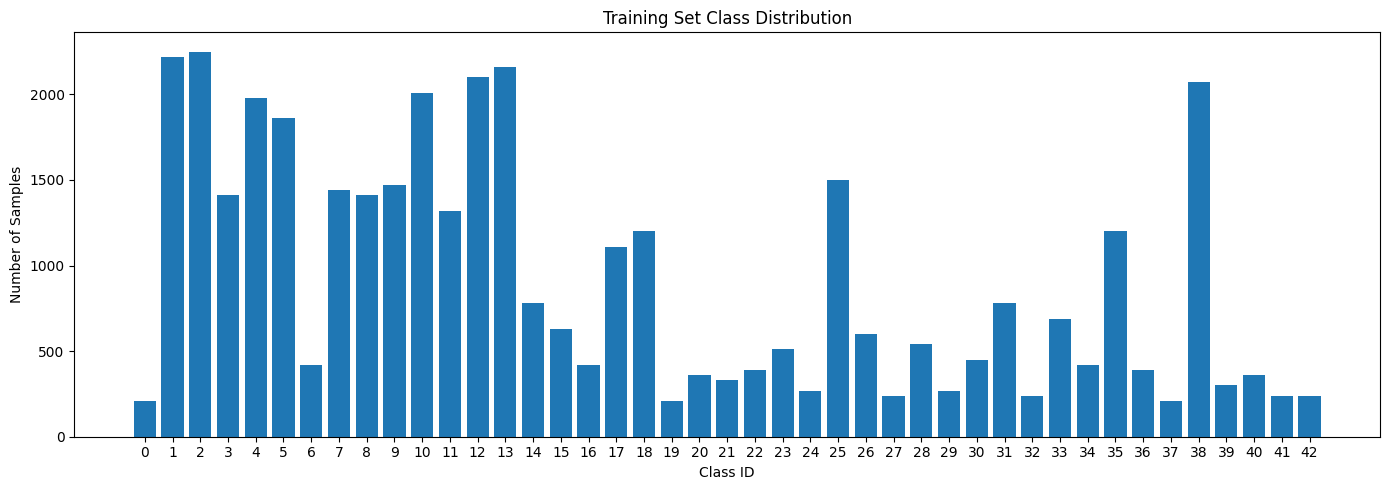

In [ ]:
import matplotlib.pyplot as plt

# Plot class distribution
counts = df['ClassId'].value_counts().sort_index()
plt.figure(figsize=(14, 5))
plt.bar(counts.index, counts.values)
plt.xlabel("Class ID")
plt.ylabel("Number of Samples")
plt.title("Training Set Class Distribution")
plt.xticks(range(0, 43))
plt.tight_layout()
plt.show()


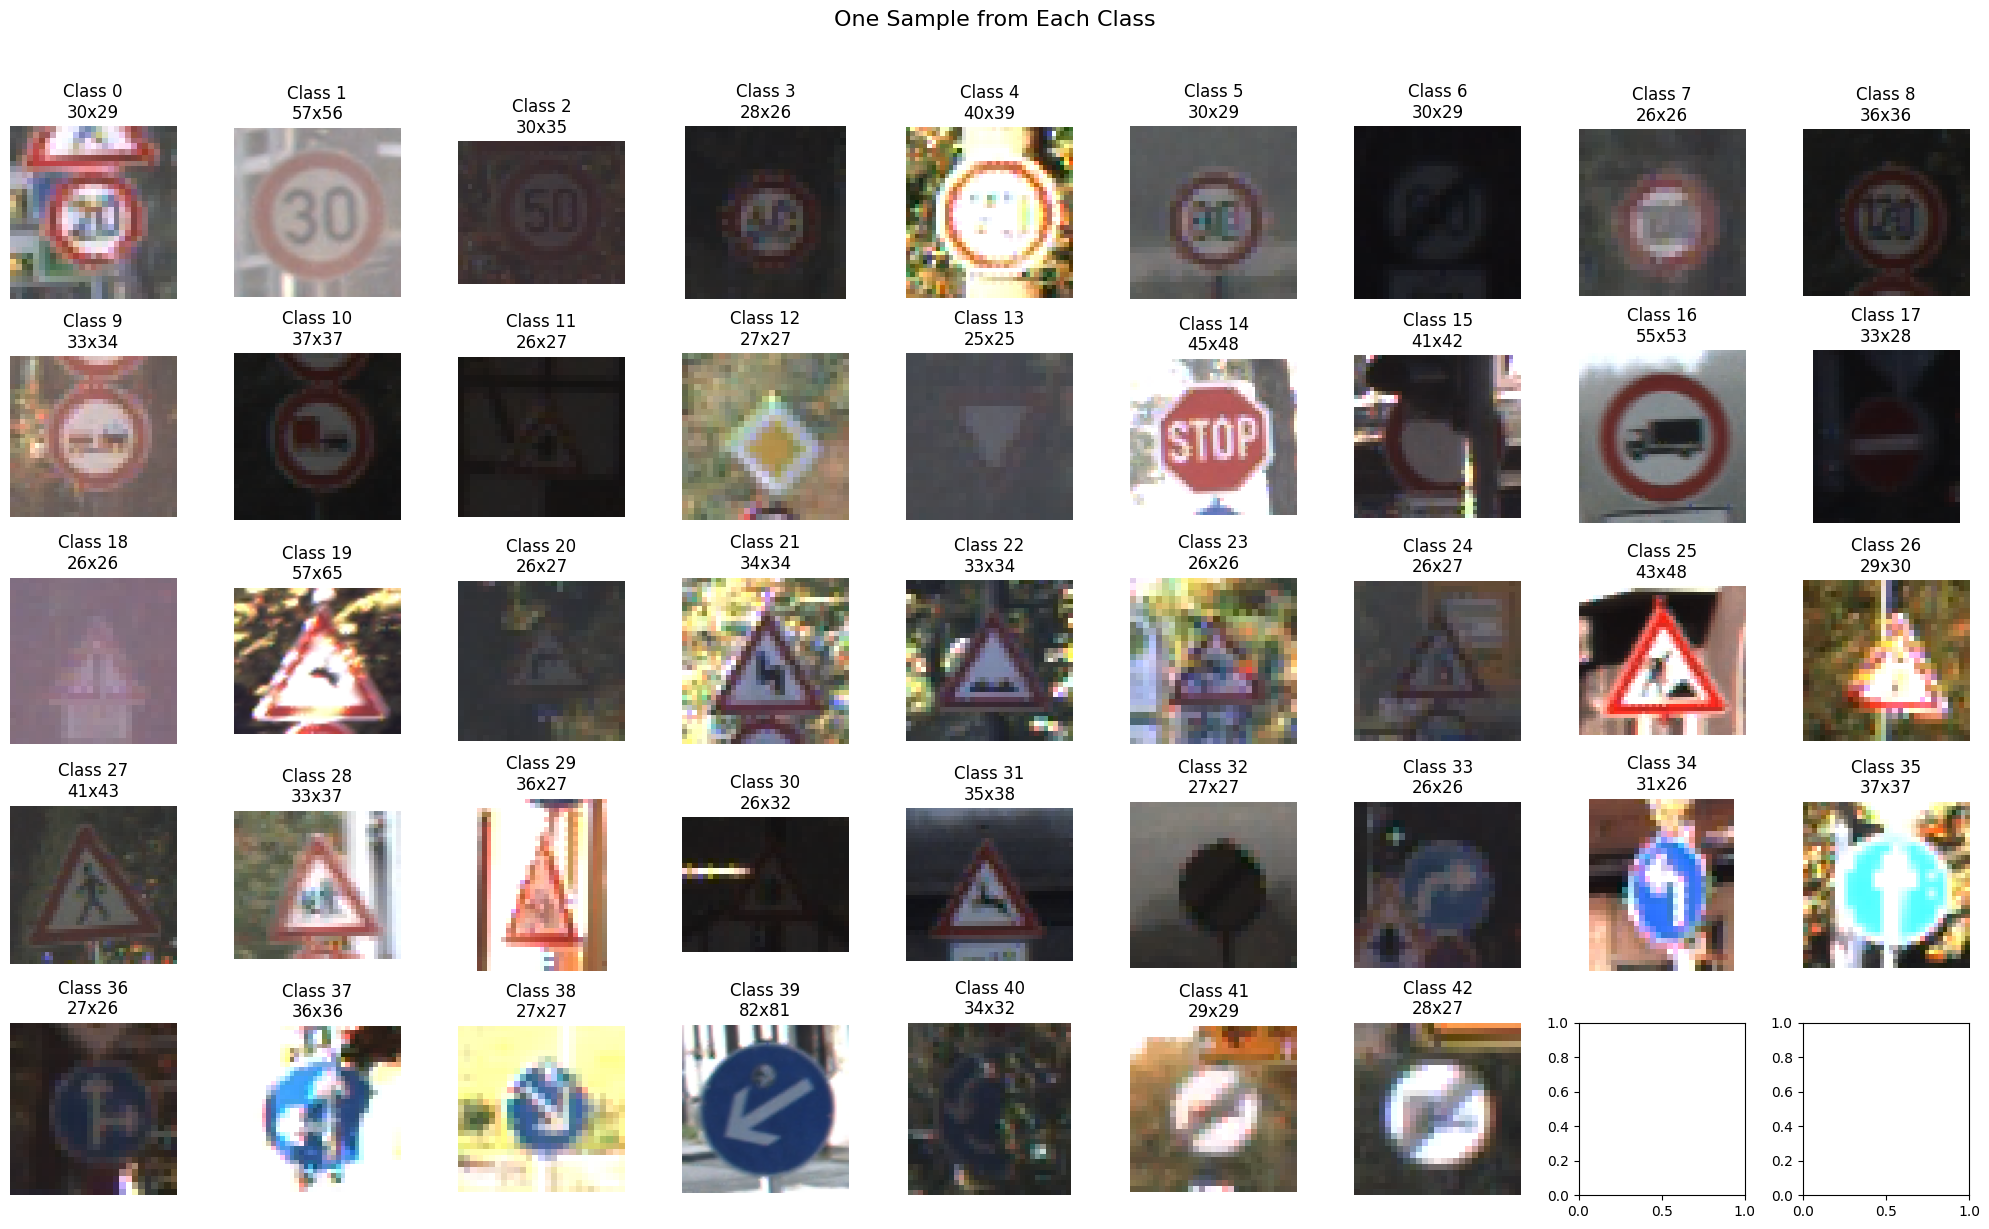

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Display sample images from each class
fig, axes = plt.subplots(5, 9, figsize=(20, 12))
axes = axes.flatten()

for cls in sorted(df['ClassId'].unique()):
    sample = df[df["ClassId"] == cls].iloc[0]
    # Path column already contains relative path from dataset root
    img_path = os.path.join(path, sample['Path'])
    img = Image.open(img_path)
    axes[cls].imshow(img)
    axes[cls].set_title(f"Class {cls}\n{img.size[1]}x{img.size[0]}")
    axes[cls].axis("off")

plt.suptitle("One Sample from Each Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Image size statistics
heights = df['Height'].value_counts().sort_index()
widths = df['Width'].value_counts().sort_index()

print("Image heights:")
print(heights)
print()
print("Image widths:")
print(widths)


Image heights:
Height
25       70
26      287
27      572
28      850
29     1111
       ... 
205       1
211       1
213       2
219       1
225       1
Name: count, Length: 176, dtype: int64

Image widths:
Width
25       54
26      341
27      711
28      910
29     1105
       ... 
226       1
229       1
230       1
231       1
243       1
Name: count, Length: 187, dtype: int64


In [ ]:
# Check test set
test_dir = os.path.join(path, "Test")
test_images = os.listdir(test_dir)
print(f"Test images: {len(test_images)}")

# Load test labels
df_test = pd.read_csv(os.path.join(path, "Test.csv"))
print(f"Test labels: {len(df_test)}")
print()
df_test.head()


Test images: 12631
Test labels: 12630



,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


## Data Preprocessing

In [ ]:
import numpy as np
from PIL import Image

TARGET_SIZE = (32, 32)  # (width, height)

def load_and_preprocess(img_path, row, mean=None, std=None):
    """
    1. Crop to the Region of Interest (ROI) from bounding box coords.
    2. Resize to a fixed target size.
    3. Normalize pixel values (0-1 scaling and optional Z-Score normalization).
    """
    img = Image.open(img_path).convert("RGB")

    # Step 1: Crop to ROI
    x1, y1 = int(row["Roi.X1"]), int(row["Roi.Y1"])
    x2, y2 = int(row["Roi.X2"]), int(row["Roi.Y2"])
    img = img.crop((x1, y1, x2, y2))

    # Step 2: Resize to fixed dimensions
    img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

    # Step 3: Base normalization to [0, 1]
    arr = np.array(img, dtype=np.float32) / 255.0

    # Optional: Apply per-channel Z-Score normalization if mean/std are provided
    if mean is not None and std is not None:
        arr = (arr - mean) / std

    return arr

# Hinweis: Im ersten Durchlauf existieren channel_mean/std noch nicht,
# daher wird hier nur auf [0,1] skaliert.
sample = df.iloc[0]
img_path = os.path.join(path, sample["Path"])
preprocessed = load_and_preprocess(img_path, sample)
print(f"Preprocessed array shape: {preprocessed.shape}")
print(f"Pixel range (0-1 only): [{preprocessed.min():.4f}, {preprocessed.max():.4f}]")

Original shape: (27, 26)
Preprocessed array shape: (32, 32, 3)
Pixel range: [0.1490, 0.4549]


In [ ]:
# Preprocess all training images
X_train = np.zeros((len(df), TARGET_SIZE[0], TARGET_SIZE[1], 3), dtype=np.float32)
y_train = df["ClassId"].values

for i, row in df.iterrows():
    img_path = os.path.join(path, row["Path"])
    X_train[i] = load_and_preprocess(img_path, row)
    if (i + 1) % 5000 == 0:
        print(f"Processed {i + 1}/{len(df)} images")

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Class distribution preserved: {np.bincount(y_train).sum() == len(df)}")


Processed 5000/39209 images
Processed 10000/39209 images
Processed 15000/39209 images
Processed 20000/39209 images
Processed 25000/39209 images
Processed 30000/39209 images
Processed 35000/39209 images

X_train shape: (39209, 32, 32, 3)
y_train shape: (39209,)
Class distribution preserved: True


In [ ]:
# Preprocess all test images
X_test = np.zeros((len(df_test), TARGET_SIZE[0], TARGET_SIZE[1], 3), dtype=np.float32)
y_test = df_test["ClassId"].values

for i, row in df_test.iterrows():
    img_path = os.path.join(path, row["Path"])
    X_test[i] = load_and_preprocess(img_path, row)
    if (i + 1) % 2000 == 0:
        print(f"Processed {i + 1}/{len(df_test)} test images")

print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Processed 2000/12630 test images
Processed 4000/12630 test images
Processed 6000/12630 test images
Processed 8000/12630 test images
Processed 10000/12630 test images
Processed 12000/12630 test images

X_test shape: (12630, 32, 32, 3)
y_test shape: (12630,)


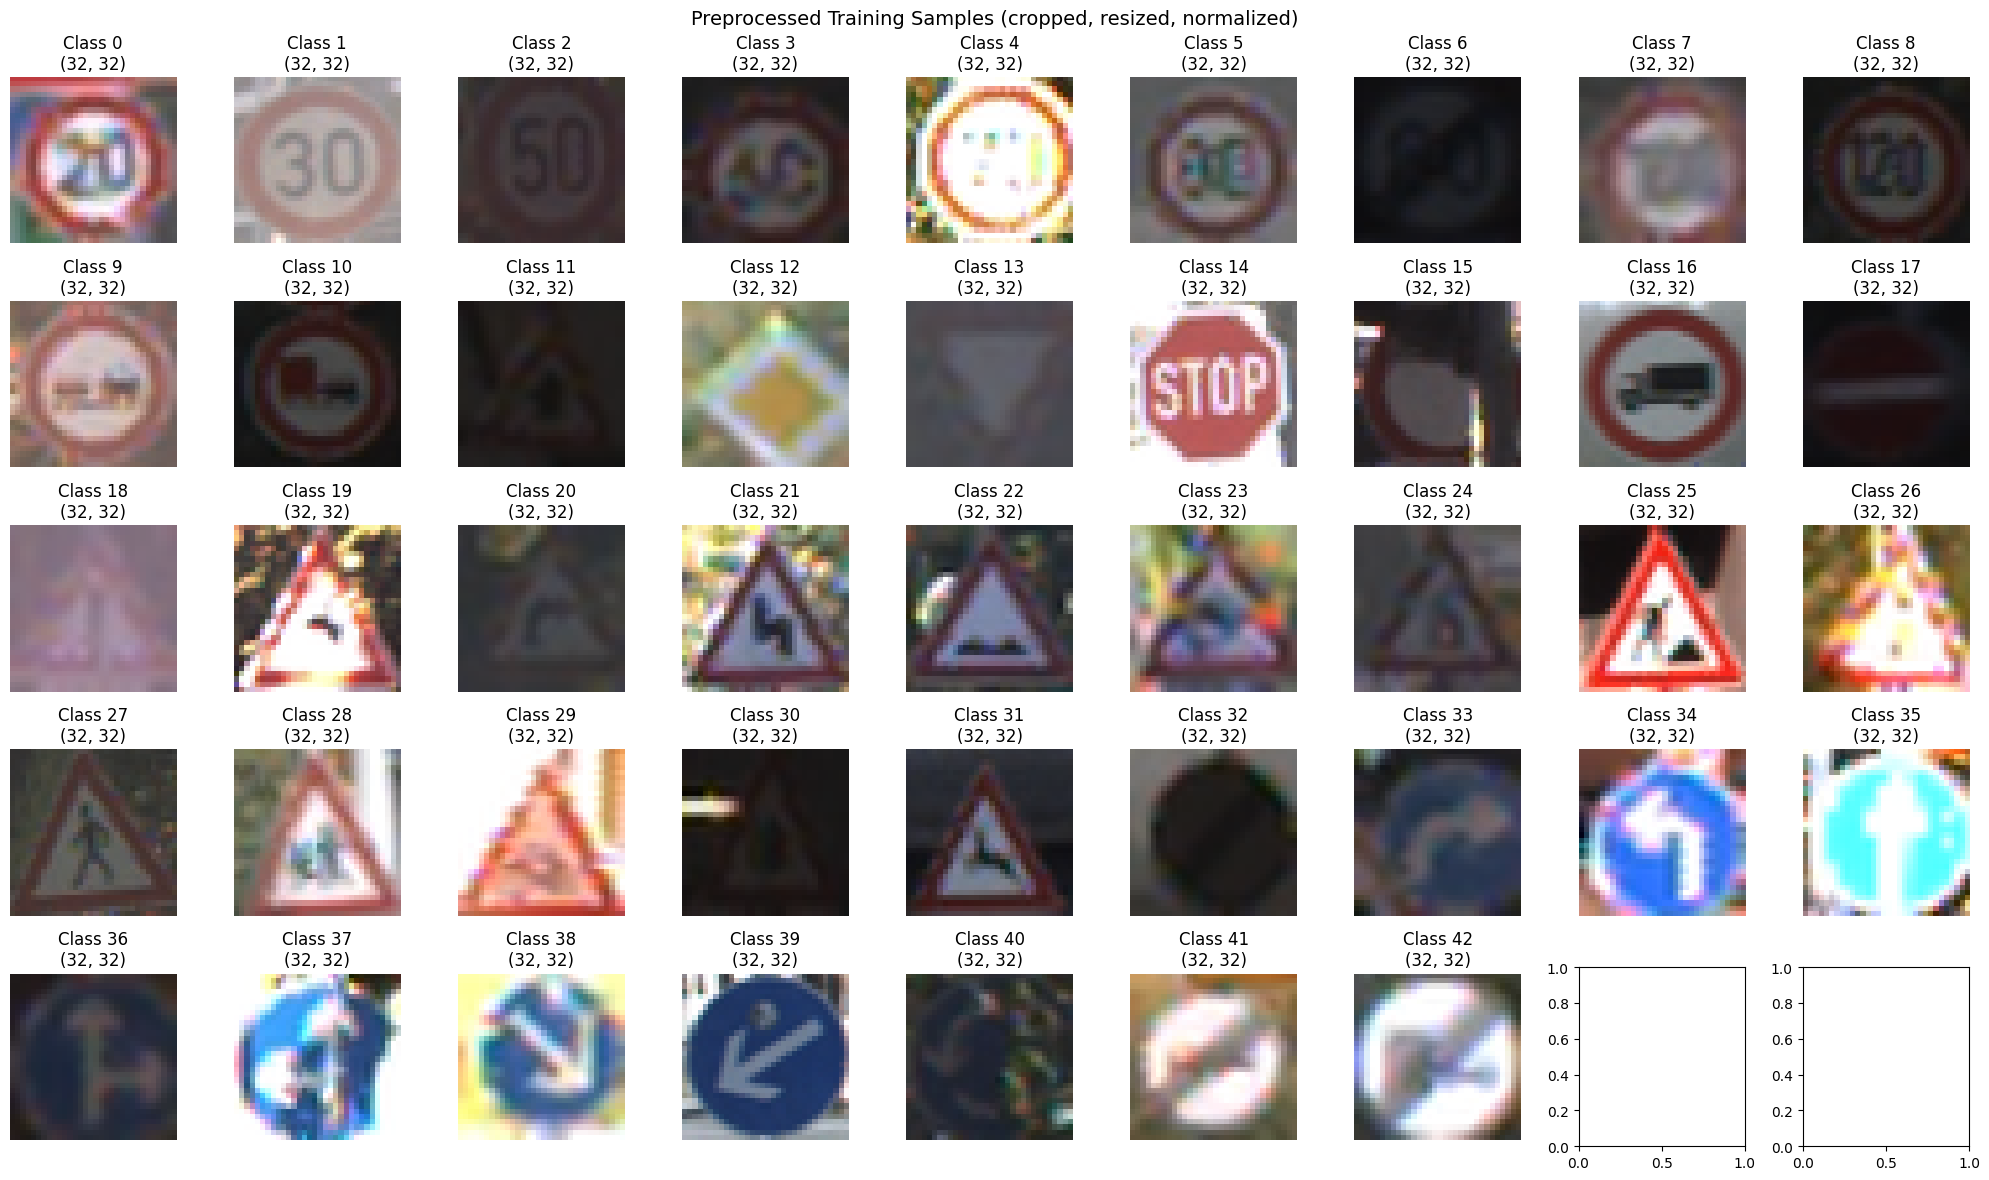

In [ ]:
# Visualize a few preprocessed samples per class
fig, axes = plt.subplots(5, 9, figsize=(20, 12))
axes = axes.flatten()

for cls in sorted(df["ClassId"].unique()):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].imshow(X_train[idx])
    axes[cls].set_title(f"Class {cls}\n{TARGET_SIZE}")
    axes[cls].axis("off")

plt.suptitle("Preprocessed Training Samples (cropped, resized, normalized)", fontsize=14)
plt.tight_layout()
plt.show()


## Class Balancing: Oversampling + Augmentation + Train/Val Split

In [ ]:
from sklearn.model_selection import train_test_split

# Reserve 15% of training data as validation set (stratified by class)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)
# NEU: Per-Channel Mean/Std NUR aus den Trainingsdaten berechnen
channel_mean = X_train.reshape(-1, 3).mean(axis=0)
channel_std = X_train.reshape(-1, 3).std(axis=0)
print(f"Mean (R,G,B): {channel_mean}")
print(f"Std  (R,G,B): {channel_std}")
def normalize(x, mean=channel_mean, std=channel_std):
    return (x - mean) / std

print(f"Train:   {X_train.shape[0]} samples")
print(f"Val:     {X_val.shape[0]} samples")
print(f"Test:    {X_test.shape[0]} samples")
print(f"Total:   {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")
print()
print("Validation class distribution (first 10 classes):")
val_counts = np.bincount(y_val, minlength=43)
for c in range(10):
    print(f"  Class {c}: {val_counts[c]}")


Mean (R,G,B): [0.31706738 0.27991173 0.294529  ]
Std  (R,G,B): [0.26339275 0.24349247 0.2552073 ]
Train:   33327 samples
Val:     5882 samples
Test:    12630 samples
Total:   51839

Validation class distribution (first 10 classes):
  Class 0: 31
  Class 1: 333
  Class 2: 338
  Class 3: 212
  Class 4: 297
  Class 5: 279
  Class 6: 63
  Class 7: 216
  Class 8: 212
  Class 9: 221


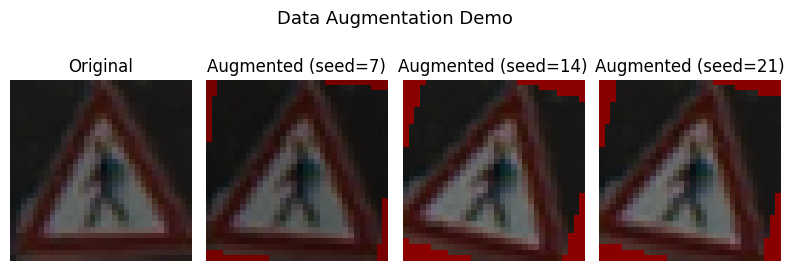

In [ ]:
import random

def augment_image(img, seed=None):
    """
    Apply random augmentation to a single image (HWC, float32 [0,1]).
    - Random rotation: ±20°
    - Random horizontal flip: 50% chance
    - Random color jitter (brightness/contrast): ±15%
    """
    if seed is not None:
        random.seed(seed)

    # Convert to PIL for transformations
    pil_img = Image.fromarray((img * 255).astype(np.uint8))

    # Random rotation (±20 degrees)
    angle = random.uniform(-20, 20)
    pil_img = pil_img.rotate(angle, resample=Image.Resampling.BICUBIC,
                             expand=False, fillcolor=128)

    # Random horizontal flip (50% chance)
    # This is bad for road sings as they rely on the horizontal direction!
    # if random.random() < 0.5:
    #     pil_img = pil_img.transpose(Image.FLIP_LEFT_RIGHT)
    # with this on:
    # Test Accuracy:  0.9734
    # F1 (macro):    0.9514
    # F1 (weighted): 0.9731

    # Convert back to array
    arr = np.array(pil_img, dtype=np.float32) / 255.0

    # Random brightness adjustment (±15%)
    brightness = random.uniform(0.85, 1.15)
    arr = np.clip(arr * brightness, 0, 1)

    # Random contrast adjustment (±15%)
    contrast = random.uniform(0.85, 1.15)
    mean = arr.mean()
    arr = np.clip((arr - mean) * contrast + mean, 0, 1)

    return arr

# Quick demo — show original vs augmented versions of one sample
demo_idx = 0
fig, axes = plt.subplots(1, 4, figsize=(8, 3))
axes[0].imshow(X_train[demo_idx])
axes[0].set_title("Original")
for i in range(1, 4):
    axes[i].imshow(augment_image(X_train[demo_idx], seed=i * 7))
    axes[i].set_title(f"Augmented (seed={i*7})")
for ax in axes:
    ax.axis("off")
plt.suptitle("Data Augmentation Demo", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Determine target count per class (use the max class size)
class_counts = np.bincount(y_train, minlength=43)
target_count = int(class_counts.max() * 1.1)  # 10% buffer above the largest class
print(f"Max class size: {class_counts.max()}, Target per class: {target_count}")
print(f"Augmentations needed per class:")
for c in range(43):
    deficit = max(0, target_count - class_counts[c])
    if deficit > 0:
        print(f"  Class {c:2d}: {class_counts[c]:5d} → need {deficit:4d} more")

# Build balanced dataset by augmenting minority classes
X_balanced = []
y_balanced = []

for cls in range(43):
    indices = np.where(y_train == cls)[0]
    X_cls = X_train[indices]

    if len(X_cls) >= target_count:
        # Already enough — take a random subset to avoid bias
        chosen = np.random.choice(len(X_cls), target_count, replace=False)
        X_balanced.append(X_cls[chosen])
        y_balanced.append(np.full(target_count, cls))
    else:
        # Oversample by augmenting existing samples
        needed = target_count - len(X_cls)
        # Pick random samples to augment (with replacement)
        aug_indices = np.random.choice(len(X_cls), needed, replace=True)
        augmented = np.array([augment_image(X_cls[j]) for j in aug_indices])
        X_balanced.append(np.vstack([X_cls, augmented]))
        y_balanced.append(np.full(target_count, cls))

    if (cls + 1) % 10 == 0:
        print(f"Processed classes {cls+1}/43")

X_balanced = np.vstack(X_balanced)
y_balanced = np.concatenate(y_balanced)

print(f"\nBalanced dataset: {X_balanced.shape[0]} samples")
print(f"Class distribution (all should be ~{target_count}):")
new_counts = np.bincount(y_balanced, minlength=43)
print(f"  Min: {new_counts.min()}, Max: {new_counts.max()}, Std: {new_counts.std():.0f}")


Max class size: 1912, Target per class: 2103
Augmentations needed per class:
  Class  0:   179 → need 1924 more
  Class  1:  1887 → need  216 more
  Class  2:  1912 → need  191 more
  Class  3:  1198 → need  905 more
  Class  4:  1683 → need  420 more
  Class  5:  1581 → need  522 more
  Class  6:   357 → need 1746 more
  Class  7:  1224 → need  879 more
  Class  8:  1198 → need  905 more
  Class  9:  1249 → need  854 more
  Class 10:  1708 → need  395 more
  Class 11:  1122 → need  981 more
  Class 12:  1785 → need  318 more
  Class 13:  1836 → need  267 more
  Class 14:   663 → need 1440 more
  Class 15:   535 → need 1568 more
  Class 16:   357 → need 1746 more
  Class 17:   943 → need 1160 more
  Class 18:  1020 → need 1083 more
  Class 19:   179 → need 1924 more
  Class 20:   306 → need 1797 more
  Class 21:   281 → need 1822 more
  Class 22:   332 → need 1771 more
  Class 23:   433 → need 1670 more
  Class 24:   230 → need 1873 more
  Class 25:  1275 → need  828 more
  Class 26:  

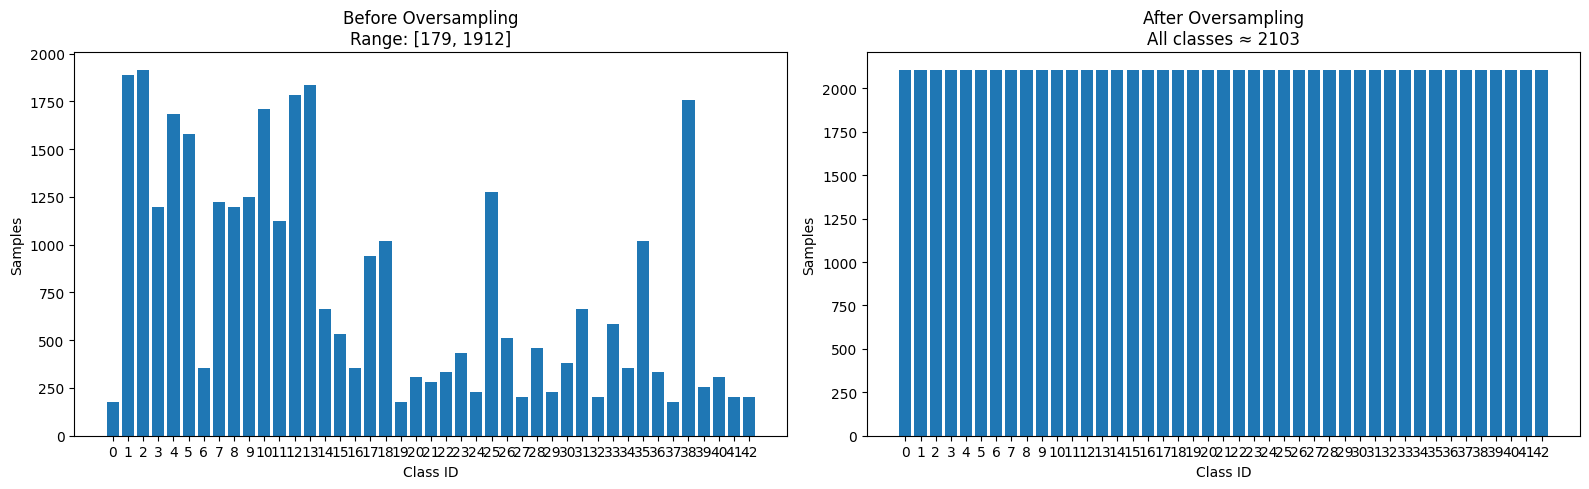

In [ ]:
# Shuffle the balanced dataset
shuffle_idx = np.random.RandomState(42).permutation(len(X_balanced))
X_balanced = X_balanced[shuffle_idx]
y_balanced = y_balanced[shuffle_idx]

# Plot before vs after
original_counts = np.bincount(y_train, minlength=43)
balanced_counts = np.bincount(y_balanced, minlength=43)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(43), original_counts)
axes[0].set_xlabel("Class ID")
axes[0].set_ylabel("Samples")
axes[0].set_title(f"Before Oversampling\nRange: [{original_counts.min()}, {original_counts.max()}]")
axes[0].set_xticks(range(43))

axes[1].bar(range(43), balanced_counts)
axes[1].set_xlabel("Class ID")
axes[1].set_ylabel("Samples")
axes[1].set_title(f"After Oversampling\nAll classes ≈ {target_count}")
axes[1].set_xticks(range(43))

plt.tight_layout()
plt.show()


## Baseline: Logistic Regression

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Flatten images and convert to tensors
X_bal_flat = torch.tensor(normalize(X_balanced).reshape(X_balanced.shape[0], -1), dtype=torch.float32).to(device)
y_bal_flat = torch.tensor(y_balanced, dtype=torch.long).to(device)
X_val_flat = torch.tensor(normalize(X_val).reshape(X_val.shape[0], -1), dtype=torch.float32).to(device)
y_val_flat = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_flat = torch.tensor(normalize(X_test).reshape(X_test.shape[0], -1), dtype=torch.float32).to(device)
y_test_flat = torch.tensor(y_test, dtype=torch.long).to(device)

# Logistic regression = single linear layer + cross-entropy
lr_model = nn.Linear(X_bal_flat.shape[1], 43).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lr_model.parameters(), lr=1e-2, weight_decay=1e-4)

# Train
train_dataset = torch.utils.data.TensorDataset(X_bal_flat, y_bal_flat)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)

for epoch in range(1, 31):
    lr_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(lr_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

    # Quick eval every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        lr_model.eval()
        with torch.no_grad():
            val_acc = (lr_model(X_val_flat).argmax(1) == y_val_flat).float().mean().item()
        print(f"Epoch {epoch:2d} | val_acc={val_acc:.4f}")

# Final test evaluation
lr_model.eval()
with torch.no_grad():
    val_pred = lr_model(X_val_flat).argmax(1).cpu().numpy()
    test_pred = lr_model(X_test_flat).argmax(1).cpu().numpy()

print(f"\nVal accuracy:   {(val_pred == y_val).mean():.4f}")
print(f"Test accuracy:  {(test_pred == y_test).mean():.4f}")


Epoch  1 | val_acc=0.8390
Epoch  5 | val_acc=0.8793
Epoch 10 | val_acc=0.8939
Epoch 15 | val_acc=0.9024
Epoch 20 | val_acc=0.9051
Epoch 25 | val_acc=0.9097
Epoch 30 | val_acc=0.9048

Val accuracy:   0.9048
Test accuracy:  0.8279


## CNN model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3x32x32 → 32x14x14
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 32x16x16

            # Block 2: → 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 64x8x8

            # Block 3: → 128x3x3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 128x4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN(num_classes=43).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params: {total_params:,} | Trainable: {trainable_params:,}")


Using device: cpu
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays to tensors (CHW format)
X_bal_t = torch.tensor(normalize(X_balanced), dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_bal_t = torch.tensor(y_balanced, dtype=torch.long).to(device)
X_val_t = torch.tensor(normalize(X_val), dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_t = torch.tensor(normalize(X_test), dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_bal_t, y_bal_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, min_lr=1e-6)

# Training loop
best_val_acc = 0.0
patience_counter = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, 51):
    # Train
    model.train()
    running_loss, correct = 0.0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(1) == y_batch).sum().item()

    train_loss = running_loss / len(X_bal_t)
    train_acc  = correct / len(X_bal_t)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validate
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            val_correct += (outputs.argmax(1) == y_batch).sum().item()

    val_loss  = val_loss / len(X_val_t)
    val_acc   = val_correct / len(X_val_t)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), './cnn_model.pth')
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if patience_counter >= 5:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch  1 | train_loss=0.2121 train_acc=0.9196 val_loss=0.0264 val_acc=0.9944
Epoch  5 | train_loss=0.1610 train_acc=0.9385 val_loss=0.0139 val_acc=0.9980
Epoch 10 | train_loss=0.0804 train_acc=0.9689 val_loss=0.0085 val_acc=0.9988
Epoch 15 | train_loss=0.0509 train_acc=0.9804 val_loss=0.0102 val_acc=0.9990
Epoch 20 | train_loss=0.0377 train_acc=0.9858 val_loss=0.0127 val_acc=0.9988

Early stopping at epoch 20

Best validation accuracy: 0.9990


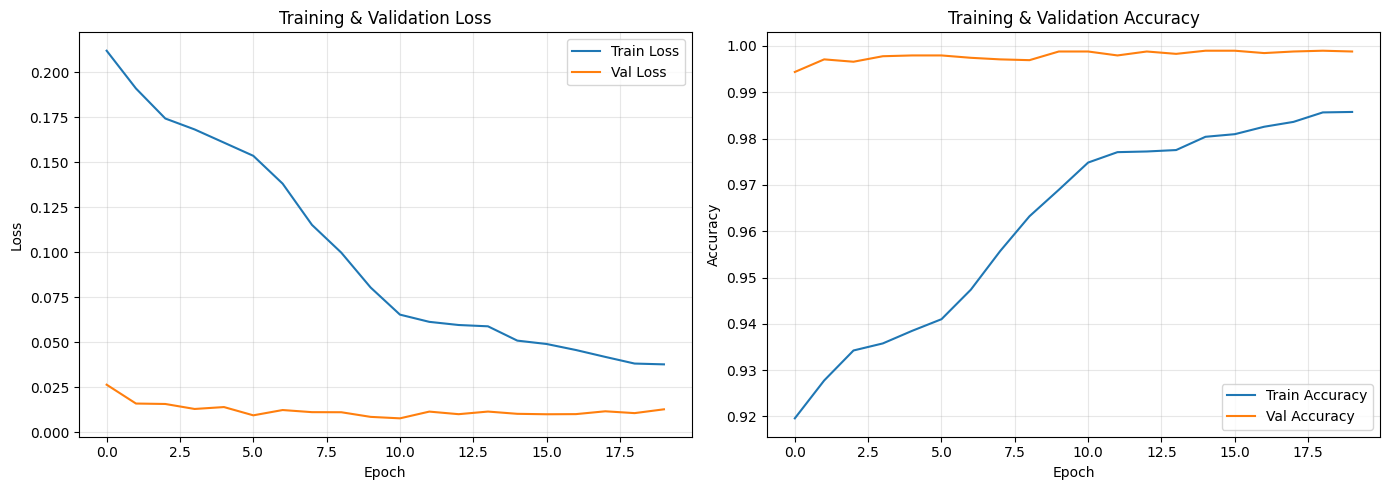

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Load best model
model.load_state_dict(torch.load('./cnn_model.pth', weights_only=True))
model.eval()

# Test evaluation
with torch.no_grad():
    outputs = model(X_test_t)
    test_loss = criterion(outputs, y_test_t).item()
    y_pred = outputs.argmax(1).cpu().numpy()
    test_acc = (y_pred == y_test).mean()

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Per-class accuracy
from collections import Counter
class_correct = Counter()
class_total   = Counter()
for true, pred in zip(y_test, y_pred):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

print("\nPer-class accuracy (bottom 10 classes):")
class_accs = {c: class_correct[c]/class_total[c] for c in range(43)}
sorted_classes = sorted(class_accs, key=class_accs.get)
for c in sorted_classes[:10]:
    print(f"  Class {c:2d}: {class_accs[c]:.2%} ({class_correct[c]}/{class_total[c]})")


Test Loss:     0.0755
Test Accuracy: 0.9881

Per-class accuracy (bottom 10 classes):
  Class 30: 90.00% (135/150)
  Class 26: 91.67% (165/180)
  Class 41: 91.67% (55/60)
  Class 42: 92.22% (83/90)
  Class  6: 93.33% (140/150)
  Class 22: 95.83% (115/120)
  Class 36: 95.83% (115/120)
  Class 18: 96.67% (377/390)
  Class 25: 97.08% (466/480)
  Class  3: 97.33% (438/450)


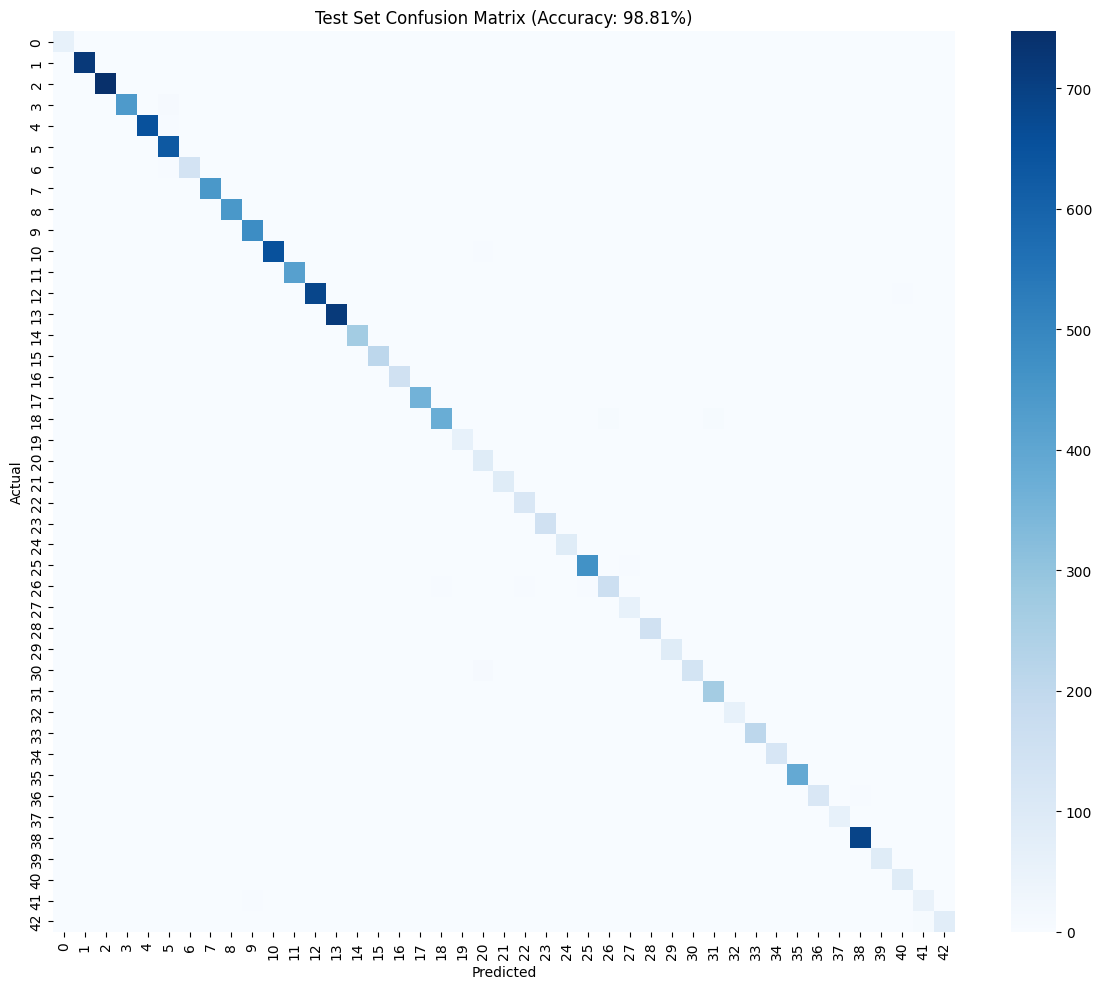

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=range(43), yticklabels=range(43))
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Test Set Confusion Matrix (Accuracy: {test_acc:.2%})')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, f1_score

# Overall F1 scores
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"F1 (macro):    {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")

# Full per-class report
print("\nPer-class Precision / Recall / F1:")
print(classification_report(y_test, y_pred,
                         target_names=[f"Class {c}" for c in range(43)],
                         digits=3))


Test Accuracy:  0.9881
F1 (macro):    0.9807
F1 (weighted): 0.9881

Per-class Precision / Recall / F1:
              precision    recall  f1-score   support

     Class 0      0.984     1.000     0.992        60
     Class 1      0.997     0.997     0.997       720
     Class 2      0.999     0.996     0.997       750
     Class 3      0.993     0.973     0.983       450
     Class 4      0.998     0.989     0.994       660
     Class 5      0.969     0.997     0.983       630
     Class 6      1.000     0.933     0.966       150
     Class 7      0.993     0.996     0.994       450
     Class 8      0.991     0.996     0.993       450
     Class 9      0.986     1.000     0.993       480
    Class 10      1.000     0.986     0.993       660
    Class 11      0.995     0.995     0.995       420
    Class 12      0.999     0.990     0.994       690
    Class 13      1.000     0.996     0.998       720
    Class 14      1.000     1.000     1.000       270
    Class 15      0.991     1.00

## Worst-Performing Classes — Quick Look

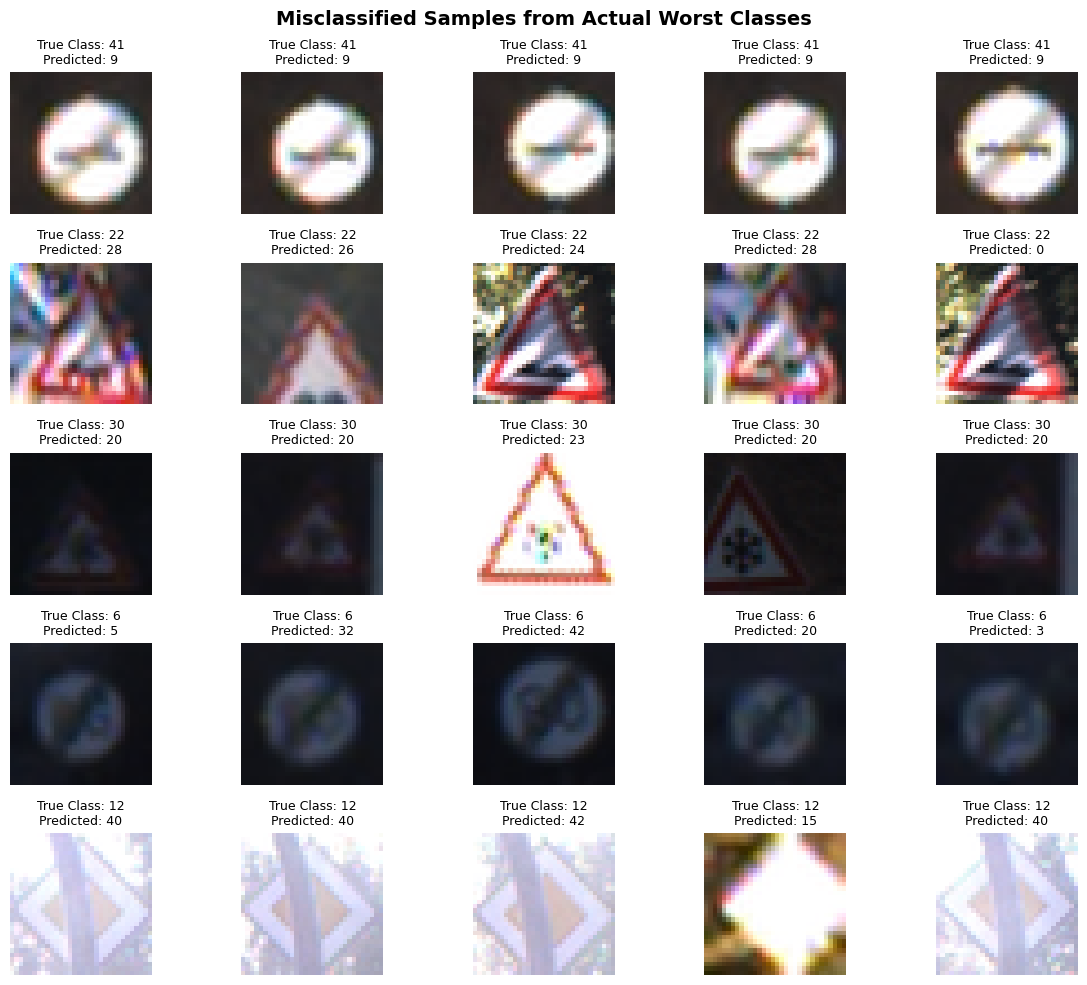

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify the worst performing classes with false negatives (Recall < 1.0)
# Class 41 (F1: 0.912), Class 22 (F1: 0.920), Class 30 (F1: 0.925), Class 6 (F1: 0.944), Class 12 (F1: 0.966)
worst_classes = [41, 22, 30, 6, 12]

fig, axes = plt.subplots(5, 5, figsize=(12, 10))

for row_idx, cls in enumerate(worst_classes):
    mask = (y_test == cls) & (y_pred != cls)
    wrong_indices = np.where(mask)[0][:5]  # Take up to 4 examples

    for col_idx in range(5):
        ax = axes[row_idx, col_idx]

        if col_idx < len(wrong_indices):
            idx = wrong_indices[col_idx]
            ax.imshow(X_test[idx])
            ax.set_title(f"True Class: {cls}\nPredicted: {y_pred[idx]}", fontsize=9)

        ax.axis("off")

plt.suptitle("Misclassified Samples from Actual Worst Classes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()